# Листок № 1. СЛАУ, матрицы, квадратичные формы
## Подробные решения задач 1.1–1.20

**Источник условий:** «Практические занятия Листок 1 (1).pdf», составитель — д.ф.-м.н., проф. П. Е. Рябов, 6 страниц.

В каждом разделе приведены условие, ход решения, вычисления и ответ. Символьные результаты получены точно; десятичные приближения явно обозначены. Проверки `assert` подтверждают подстановки, матричные равенства и граничные случаи. Рисунки встроены в файл.

**Запуск:** Python 3.10+; выполните ячейки сверху вниз командой **Run All / Выполнить все**. Нужны `numpy`, `sympy`, `matplotlib`, `IPython`. Если библиотек нет, раскомментируйте следующую ячейку. Все вычисленные результаты уже сохранены.

**Замечания к условиям:** в № 1.12 используется семейство матриц Адамара конструкции Сильвестра; перестановка строк на рисунке разобрана отдельно. В № 1.20 исходный PDF содержит линейный член $2x_1$; приведены буквальное прочтение и решение при предполагаемом исправлении $2x_1^2$.

In [1]:
# При необходимости установите зависимости, затем перезапустите ядро:
# %pip install numpy sympy matplotlib ipython

In [2]:
import math
from itertools import combinations, permutations
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from IPython.display import display, Markdown, Math

sp.init_printing()
np.set_printoptions(precision=9, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "font.family": "DejaVu Sans", "font.size": 11})
answers = {}
def show(label, value):
    display(Markdown(f"**{label}**"))
    display(value)
def answer(task, text):
    answers[task] = text
    display(Markdown(f"**Ответ {task}:** {text}"))

def poly_at_matrix(poly, matrix, variable):
    """Вычисление многочлена от матрицы по схеме Горнера."""
    result = sp.zeros(matrix.rows)
    for coefficient in sp.Poly(poly, variable).all_coeffs():
        result = result * matrix + coefficient * sp.eye(matrix.rows)
    return result

## 1.1. Общее решение СЛАУ

**Условие.**
$$\begin{cases}x_1+5x_2-2x_3=-7,\\-3x_1+x_2+9x_3-5x_4=9,\\4x_1-8x_2-x_3+7x_4=0.\end{cases}$$

**Решение.** Приведём расширенную матрицу $(A\mid b)$ к приведённому ступенчатому виду (RREF). Три ведущих столбца соответствуют $x_1,x_2,x_3$; переменная $x_4=t$ свободна. Ранги основной и расширенной матриц равны 3, поэтому система совместна и имеет один свободный параметр.

In [3]:
A11 = sp.Matrix([[1,5,-2,0],[-3,1,9,-5],[4,-8,-1,7]])
b11 = sp.Matrix([-7,9,0])
R11, pivots11 = A11.row_join(b11).rref()
show('RREF расширенной матрицы', R11)
t = sp.symbols('t', real=True)
x11 = sp.Matrix([(-11-8*t)/7, (-6+2*t)/7, (4+t)/7, t])
show('Общее решение', x11)
assert A11*x11 == b11
assert A11.rank() == A11.row_join(b11).rank() == 3
answer('1.1', r'$x=\left(\frac{-11-8t}{7},\frac{-6+2t}{7},\frac{4+t}{7},t\right)^T$, $t\in\mathbb R$.')

**RREF расширенной матрицы**

⎡1  0  0  8/7   -11/7⎤
⎢                    ⎥
⎢0  1  0  -2/7  -6/7 ⎥
⎢                    ⎥
⎣0  0  1  -1/7   4/7 ⎦

**Общее решение**

⎡  8⋅t   11⎤
⎢- ─── - ──⎥
⎢   7    7 ⎥
⎢          ⎥
⎢ 2⋅t   6  ⎥
⎢ ─── - ─  ⎥
⎢  7    7  ⎥
⎢          ⎥
⎢  t   4   ⎥
⎢  ─ + ─   ⎥
⎢  7   7   ⎥
⎢          ⎥
⎣    t     ⎦

**Ответ 1.1:** $x=\left(\frac{-11-8t}{7},\frac{-6+2t}{7},\frac{4+t}{7},t\right)^T$, $t\in\mathbb R$.

## 1.2. RREF и общее решение

**Условие.**
$$\begin{cases}5x_1-x_2+5x_3+9x_4-2x_5=-3,\\3x_1+6x_3+9x_4-x_5=4,\\2x_1+4x_3+6x_4-x_5=0.\end{cases}$$

**Решение.** После исключения Гаусса ведущими будут $x_1,x_2,x_5$. Полагая $x_3=s$, $x_4=t$, из строк RREF получаем $x_1=4-2s-3t$, $x_2=7-5s-6t$, $x_5=8$. Два свободных параметра соответствуют разности числа неизвестных и ранга: $5-3=2$.

In [4]:
A12 = sp.Matrix([[5,-1,5,9,-2],[3,0,6,9,-1],[2,0,4,6,-1]])
b12 = sp.Matrix([-3,4,0])
R12, pivots12 = A12.row_join(b12).rref()
show('а) RREF', R12)
s = sp.symbols('s', real=True)
x12 = sp.Matrix([4-2*s-3*t, 7-5*s-6*t, s, t, 8])
show('б) Общее решение', x12)
assert A12*x12 == b12
assert pivots12 == (0,1,4)
answer('1.2', r'$x=(4-2s-3t,\ 7-5s-6t,\ s,\ t,\ 8)^T$, $s,t\in\mathbb R$.')

**а) RREF**

⎡1  0  2  3  0  4⎤
⎢                ⎥
⎢0  1  5  6  0  7⎥
⎢                ⎥
⎣0  0  0  0  1  8⎦

**б) Общее решение**

⎡-2⋅s - 3⋅t + 4⎤
⎢              ⎥
⎢-5⋅s - 6⋅t + 7⎥
⎢              ⎥
⎢      s       ⎥
⎢              ⎥
⎢      t       ⎥
⎢              ⎥
⎣      8       ⎦

**Ответ 1.2:** $x=(4-2s-3t,\ 7-5s-6t,\ s,\ t,\ 8)^T$, $s,t\in\mathbb R$.

## 1.3. Представление $y=a+bx$

**Условие.**
$$\begin{cases}32x+97y+90z+48u=47,\\35x+84y+91z+54u=40,\\17x+18y+21z+13u=37.\end{cases}$$

**Решение.** Перенесём члены с $x$ вправо. Получается квадратная система для $(y,z,u)$:
$$C\begin{pmatrix}y\\z\\u\end{pmatrix}=d-vx,\qquad
C=\begin{pmatrix}97&90&48\\84&91&54\\18&21&13\end{pmatrix}.$$
Если $\det C\ne0$, то при любом $x$ существует единственное решение $C^{-1}d-C^{-1}vx$. Его первая координата линейна по $x$. Свободный член зависит также от правой части исходной системы (она входит в фиксированные данные условия).

In [5]:
C13 = sp.Matrix([[97,90,48],[84,91,54],[18,21,13]])
d13 = sp.Matrix([47,40,37]); v13 = sp.Matrix([32,35,17])
x = sp.symbols('x', real=True)
yzu13 = C13.inv()*(d13-v13*x)
show('Определитель C', C13.det())
show('Вектор (y,z,u)', yzu13)
a13 = yzu13[0].subs(x,0); b13 = sp.diff(yzu13[0],x)
assert C13*yzu13 == d13-v13*x
assert (a13,b13) == (14027,-4262)
answer('1.3', f'$y={a13}{int(b13):+}x$; $a={a13}$, $b={b13}$.'.replace('+-','-'))

**Определитель C**

**Вектор (y,z,u)**

⎡14027 - 4262⋅x ⎤
⎢               ⎥
⎢10447⋅x - 34382⎥
⎢               ⎥
⎣36121 - 10976⋅x⎦

**Ответ 1.3:** $y=14027-4262x$; $a=14027$, $b=-4262$.

## 1.4. Умножение и сложение матриц

**Условие.** Вычислить $UV+W$ для матриц, приведённых в следующей ячейке.

**Решение.** Размеры $U,V,W$ равны $4\times3$, $3\times4$, $4\times4$. Произведение определено и имеет размер $4\times4$.
Каждый элемент находится по формуле $(UV+W)_{ij}=\sum_{k=1}^3U_{ik}V_{kj}+W_{ij}$.
Например, элемент $(1,1)$ равен $3\cdot1+0\cdot(-2)+2\cdot2+0=7$.

In [6]:
U14 = sp.Matrix([[3,0,2],[0,1,3],[2,2,0],[0,1,0]])
V14 = sp.Matrix([[1,2,-1,2],[-2,-1,1,2],[2,1,1,2]])
W14 = sp.Matrix([[0,-4,6,1],[2,2,-5,-2],[2,-2,6,4],[1,3,0,1]])
for label, matrix in [('U',U14),('V',V14),('W',W14)]: show(label,matrix)
result14 = U14*V14+W14
show('Результат UV+W',result14)
assert result14 == sp.Matrix(4,4,lambda i,j: sum(U14[i,k]*V14[k,j] for k in range(3))+W14[i,j])
answer('1.4', '$'+sp.latex(result14)+'$.')

**U**

⎡3  0  2⎤
⎢       ⎥
⎢0  1  3⎥
⎢       ⎥
⎢2  2  0⎥
⎢       ⎥
⎣0  1  0⎦

**V**

⎡1   2   -1  2⎤
⎢             ⎥
⎢-2  -1  1   2⎥
⎢             ⎥
⎣2   1   1   2⎦

**W**

⎡0  -4  6   1 ⎤
⎢             ⎥
⎢2  2   -5  -2⎥
⎢             ⎥
⎢2  -2  6   4 ⎥
⎢             ⎥
⎣1  3   0   1 ⎦

**Результат UV+W**

⎡7   4  5   11⎤
⎢             ⎥
⎢6   4  -1  6 ⎥
⎢             ⎥
⎢0   0  6   12⎥
⎢             ⎥
⎣-1  2  1   3 ⎦

**Ответ 1.4:** $\left[\begin{matrix}7 & 4 & 5 & 11\\6 & 4 & -1 & 6\\0 & 0 & 6 & 12\\-1 & 2 & 1 & 3\end{matrix}\right]$.

## 1.5. Определители общего порядка

**Условие.** Найти определители $n\times n$ матриц с элементами: а) $\min(i,j)$; б) $\max(i,j)$; в) $|i-j|$, где $1\le i,j\le n$.

**Решение.** Используем матрицу разностей $T$: единицы на диагонали, $-1$ непосредственно под ней, остальные элементы нулевые. Умножение слева вычитает из каждой строки предыдущую исходную строку, справа на $T^T$ — аналогично действует на столбцы. Поскольку $\det T=1$, определитель $TAT^T$ совпадает с $\det A$.

**а)** Для $A_{ij}=\min(i,j)$ получается $TAT^T=I_n$, поэтому $\boxed{\det A=1}$.

**б)** Для $A_{ij}=\max(i,j)$ при $n\ge2$ получаем
$$TAT^T=\begin{pmatrix}1&\mathbf1^T\\\mathbf1&-I_{n-1}\end{pmatrix}.$$
По формуле определителя блочной матрицы $\det\begin{pmatrix}a&b^T\\c&D\end{pmatrix}=\det D\,(a-b^TD^{-1}c)$ имеем
$$\boxed{\det A=(-1)^{n-1}n}.$$
При $n=1$ эта формула также даёт 1.

**в)** Для $A_{ij}=|i-j|$ при $n\ge2$ имеем
$$TAT^T=\begin{pmatrix}0&\mathbf1^T\\\mathbf1&-2I_{n-1}\end{pmatrix},$$
следовательно,
$$\det A=(-2)^{n-1}\frac{n-1}{2}=\boxed{(-1)^{n-1}(n-1)2^{n-2}}.$$
При $n=1$ матрица равна $(0)$ и определитель равен 0. Здесь $\mathbf1$ — столбец из $n-1$ единиц.

In [7]:
checks15 = []
for n in range(1,9):
    Amin = sp.Matrix(n,n,lambda i,j: min(i+1,j+1))
    Amax = sp.Matrix(n,n,lambda i,j: max(i+1,j+1))
    Adist = sp.Matrix(n,n,lambda i,j: abs(i-j))
    expected = (1,(-1)**(n-1)*n,0 if n==1 else (-1)**(n-1)*(n-1)*2**(n-2))
    actual = (Amin.det(),Amax.det(),Adist.det())
    assert actual == expected
    checks15.append((n,*actual))
show('Столбцы: n, det(min), det(max), det(|i-j|)',sp.Matrix(checks15))
answer('1.5', r'а) $1$; б) $(-1)^{n-1}n$; в) $(-1)^{n-1}(n-1)2^{n-2}$ при $n\ge2$, при $n=1$ — $0$.')

**Столбцы: n, det(min), det(max), det(|i-j|)**

⎡1  1  1    0  ⎤
⎢              ⎥
⎢2  1  -2   -1 ⎥
⎢              ⎥
⎢3  1  3    4  ⎥
⎢              ⎥
⎢4  1  -4  -12 ⎥
⎢              ⎥
⎢5  1  5    32 ⎥
⎢              ⎥
⎢6  1  -6  -80 ⎥
⎢              ⎥
⎢7  1  7   192 ⎥
⎢              ⎥
⎣8  1  -8  -448⎦

**Ответ 1.5:** а) $1$; б) $(-1)^{n-1}n$; в) $(-1)^{n-1}(n-1)2^{n-2}$ при $n\ge2$, при $n=1$ — $0$.

## 1.6. Максимальный определитель порядка 6

**Условие.** Найти наибольший определитель матрицы $6\times6$ с элементами из $\{-1,0,1\}$.

**Решение: сведение к полному точному перебору.**

1. Определитель линеен по каждому элементу отдельно. При фиксированных остальных элементах значение в нуле — среднее значений в $-1$ и $1$. Поэтому нули можно последовательно заменить на знаки так, чтобы определитель не уменьшился. Достаточно матриц из $\{-1,1\}$.
2. Изменениями знаков строк и столбцов приведём первую строку и первый столбец к единицам. Модуль определителя сохраняется. Максимум определителя совпадает с максимумом его модуля: знак меняется перестановкой двух строк.
3. Вычтем первую строку из остальных. Получим $\det A=(-2)^5\det C$, где $C$ — матрица $5\times5$ из нулей и единиц. Обратно, любой такой $C$ задаёт нормализованную матрицу $A$ с нижним правым блоком $J-2C$.
4. Для ненулевого определителя строки $C$ ненулевые и попарно различны. Таких строк $2^5-1=31$; порядок строк влияет только на знак. Поэтому достаточно $\binom{31}{5}=169\,911$ наборов.
5. Переберём **все** наборы и посчитаем определители целочисленно по формуле Лейбница. Таким образом проверяется глобальный максимум, без округлений и случайного поиска.

Максимум $|\det C|$ равен 5, значит искомое значение равно $32\cdot5=\boxed{160}$. Следующая ячейка воспроизводит весь перебор и предъявляет матрицу, достигающую 160. Требуется несколько десятков мегабайт памяти.

In [8]:
row_patterns = ((np.arange(1,32)[:,None] >> np.arange(5)) & 1).astype(np.int64)
choices = np.array(list(combinations(range(31),5)), dtype=np.int16)
matrices = row_patterns[choices]
determinants = np.zeros(len(choices),dtype=np.int64)
for perm in permutations(range(5)):
    inversions = sum(perm[i]>perm[j] for i in range(5) for j in range(i+1,5))
    sign = (-1)**inversions
    determinants += sign*np.prod(matrices[:,np.arange(5),list(perm)],axis=1)
index = int(np.argmax(np.abs(determinants)))
C16 = sp.Matrix(matrices[index].tolist())
A16 = sp.ones(6)
A16[1:6,1:6] = sp.ones(5)-2*C16
if A16.det()<0:
    A16.row_swap(0,1)
maxdet16 = 32*int(np.abs(determinants).max())
print('Число проверенных наборов:',len(choices))
print('Максимальный модуль det(C):',int(np.abs(determinants).max()))
show('Матрица с максимальным положительным определителем',A16)
show('Её точный определитель',A16.det())
assert len(choices)==math.comb(31,5)==169911
assert maxdet16==A16.det()==160
assert all(value in (-1,1) for value in A16)
del matrices, determinants, choices
answer('1.6', '$160$; глобальный максимум подтверждён полным точным перебором после сведения.')

Число проверенных наборов: 169911
Максимальный модуль det(C): 5


**Матрица с максимальным положительным определителем**

⎡1  -1  -1  1   1   1 ⎤
⎢                     ⎥
⎢1  1   1   1   1   1 ⎥
⎢                     ⎥
⎢1  -1  1   -1  1   1 ⎥
⎢                     ⎥
⎢1  1   -1  -1  -1  1 ⎥
⎢                     ⎥
⎢1  1   -1  -1  1   -1⎥
⎢                     ⎥
⎣1  -1  1   1   -1  -1⎦

**Её точный определитель**

**Ответ 1.6:** $160$; глобальный максимум подтверждён полным точным перебором после сведения.

## 1.7. Определитель и след обратной матрицы размера 80 000

**Условие.** Диагональ — арифметическая прогрессия от $0{,}99$ до $1{,}01$; вне диагонали ненулевые только $a_{12}=0{,}57$, $a_{21}=0{,}03$. Найти $\det A$ и $\operatorname{tr}(A^{-1})$.

**Решение.** Обозначим $d_i=0{,}99+(i-1)\dfrac{0{,}02}{n-1}$. Матрица блочно-диагональная: первый блок
$$C=\begin{pmatrix}d_1&0{,}57\\0{,}03&d_2\end{pmatrix},\qquad \Delta=d_1d_2-0{,}57\cdot0{,}03,$$
а остальные блоки — числа $d_3,\ldots,d_n$.
Поэтому
$$\det A=\Delta\prod_{i=3}^n d_i,\qquad
\operatorname{tr}(A^{-1})=\frac{d_1+d_2}{\Delta}+\sum_{i=3}^n\frac1{d_i}.$$
Произведение вычисляем как $\exp(\sum\log d_i)$; для сумм используем `math.fsum`. Храним только диагональ, поскольку полная матрица `float64` заняла бы 51,2 ГБ.

In [9]:
n17=80000
d17=np.linspace(0.99,1.01,n17)
delta17=d17[0]*d17[1]-0.57*0.03
det17=math.exp(math.log(delta17)+math.fsum(np.log(d17[2:])))
trace17=(d17[0]+d17[1])/delta17+math.fsum(1/d17[2:])
print(f'det(A) = {det17:.12f}')
print(f'tr(A⁻¹) = {trace17:.12f}')
# Независимая проверка формул на небольшой матрице той же структуры.
d_small=np.linspace(0.99,1.01,8)
A_small=np.diag(d_small); A_small[0,1]=0.57; A_small[1,0]=0.03
delta_small=d_small[0]*d_small[1]-0.57*0.03
assert np.isclose(np.linalg.det(A_small),delta_small*np.prod(d_small[2:]))
assert np.isclose(np.trace(np.linalg.inv(A_small)),(d_small[0]+d_small[1])/delta_small+sum(1/d_small[2:]))
assert round(det17,3)==0.259 and round(trace17,3)==80002.703
answer('1.7', f'$\\det A\\approx {det17:.9f}$; $\\operatorname{{tr}}(A^{{-1}})\\approx {trace17:.9f}$.')

det(A) = 0.258979113865
tr(A⁻¹) = 80002.702766086004


**Ответ 1.7:** $\det A\approx 0.258979114$; $\operatorname{tr}(A^{-1})\approx 80002.702766086$.

## 1.8. Обратная матрица размера 43 000

**Условие.** Диагональ — геометрическая прогрессия от 1 до $1{,}07$; первая строка — арифметическая прогрессия от 1 до $1{,}10$. Остальные внедиагональные элементы нулевые. Найти $B=A^{-1}$, её минимальный элемент и сумму элементов.

**Решение.** Положим $q=1{,}07^{1/(n-1)}$, $d_j=q^{j-1}$, $r_j=1+0{,}10(j-1)/(n-1)$.
Из уравнения $AB=I$ получаем полное описание обратной матрицы:
$$B_{ij}=\begin{cases}
1,&i=j=1,\\
q^{-(i-1)},&i=j\ge2,\\
-r_jq^{-(j-1)},&i=1,\ j\ge2,\\
0,&\text{иначе}.
\end{cases}$$
В первой строке произведения $AB$ при $j\ge2$ слагаемые $B_{1j}+r_jB_{jj}$ взаимно уничтожаются.

Чтобы найти минимум, рассмотрим $g(t)=(1+0{,}10t)1{,}07^{-t}$, $0\le t\le1$. Логарифмическая производная $g'(t)/g(t)=0{,}10/(1+0{,}10t)-\log(1{,}07)>0$ на всём отрезке. Значит наиболее отрицательный элемент — $B_{1n}=-1{,}10/1{,}07$.
Сумму считаем без вычитания двух больших близких сумм:
$$\sum_{i,j}B_{ij}=1+\sum_{j=2}^n\frac{1-r_j}{d_j}
=1-\frac{0{,}10}{n-1}\sum_{k=1}^{n-1}kq^{-k}.$$

In [10]:
n18=43000
k18=np.arange(n18,dtype=np.float64)
d18=np.exp(np.log(1.07)*k18/(n18-1))
r18=1+0.10*k18/(n18-1)
B18_diag=1/d18
B18_first_row=-r18/d18; B18_first_row[0]=1
minimum18=float(B18_first_row.min())
sum18=1-math.fsum((0.10*k18[1:]/(n18-1))/d18[1:])
print(f'Минимум B = {minimum18:.12f}; позиция (1, {n18})')
print(f'Сумма элементов B = {sum18:.12f}')
assert np.allclose(B18_first_row[1:]+r18[1:]*B18_diag[1:],0)
assert np.allclose(d18*B18_diag,1)
assert np.isclose(minimum18,-1.10/1.07)
assert round(sum18,1)==-2054.4
answer('1.8', f'$\\min B_{{ij}}=-110/107\\approx {minimum18:.9f}$; $\\sum B_{{ij}}\\approx {sum18:.6f}$.')

Минимум B = -1.028037383178; позиция (1, 43000)
Сумма элементов B = -2054.438267008651


**Ответ 1.8:** $\min B_{ij}=-110/107\approx -1.028037383$; $\sum B_{ij}\approx -2054.438267$.

## 1.9. Суммы степеней матрицы

**Условие.** $A=0{,}057\begin{pmatrix}7&14\\9&1\end{pmatrix}$, $S_{m,n}=\sum_{i=m}^nA^i$, $B_m=(I-A)^{-1}A^m$.
Найти максимальные элементы $S_{4,70}$ и $B_4$, затем наименьшее целое $k$, при котором для любого $n>k$ все элементы $S_{k,n}$ меньше $0{,}0002$.

**Решение.** Собственные значения $\begin{pmatrix}7&14\\9&1\end{pmatrix}$ равны $4\pm3\sqrt{15}$, поэтому $\rho(A)=0{,}057(4+3\sqrt{15})<1$. Матричный геометрический ряд сходится:
$$S_{m,n}=(I-A)^{-1}(A^m-A^{n+1}),\qquad B_m=\sum_{i=m}^{\infty}A^i.$$
Все элементы $A$ положительны, поэтому частичные суммы возрастают поэлементно и строго меньше соответствующих элементов $B_m$. Следовательно, условие «для любого $n>k$» эквивалентно $\max_{i,j}(B_k)_{ij}\le0{,}0002$. Равенство здесь допустимо, поскольку конечные суммы строго меньше предела. Если предел превышает порог, некоторая конечная сумма также его превысит.

Достаточно последовательно проверять хвосты $B_k$. Они убывают: $B_k-B_{k+1}=A^k>0$ для $k\ge1$. Проверка $k-1$ докажет минимальность найденного $k$.

In [11]:
A19=0.057*np.array([[7.,14.],[9.,1.]])
I19=np.eye(2)
rho19=max(abs(np.linalg.eigvals(A19)))
S19=np.linalg.solve(I19-A19,np.linalg.matrix_power(A19,4)-np.linalg.matrix_power(A19,71))
B19=np.linalg.solve(I19-A19,np.linalg.matrix_power(A19,4))
print('Спектральный радиус:',rho19)
show('S₄,₇₀',S19); show('B₄',B19)
threshold19=0.0002
k19=0; power19=I19.copy()
while True:
    tail19=np.linalg.solve(I19-A19,power19)
    if tail19.max()<=threshold19:
        break
    k19+=1
    power19=power19@A19
previous19=np.linalg.solve(I19-A19,np.linalg.matrix_power(A19,k19-1))
print(f'max B_{k19-1} = {previous19.max():.12f}')
print(f'max B_{k19} = {tail19.max():.12f}')
# Конкретный контрпример для предыдущего k.
n_counter19=k19
while True:
    partial19=np.linalg.solve(I19-A19,np.linalg.matrix_power(A19,k19-1)-np.linalg.matrix_power(A19,n_counter19+1))
    if partial19.max()>=threshold19:
        break
    n_counter19+=1
print(f'При k={k19-1}, n={n_counter19}: max S = {partial19.max():.12f}, условие нарушено.')
assert rho19<1 and previous19.max()>threshold19>=tail19.max()
assert np.allclose(S19,sum((np.linalg.matrix_power(A19,i) for i in range(4,71)),np.zeros((2,2))))
assert k19==89
answer('1.9', f'$\\max S_{{4,70}}\\approx {S19.max():.6f}$; $\\max B_4\\approx {B19.max():.6f}$; $k_{{\\min}}={k19}$.')

Спектральный радиус: 0.8902801522014684


**S₄,₇₀**

array([[3.609679031, 3.433099565],
       [2.206992578, 2.138350646]])

**B₄**

array([[3.611174678, 3.434531889],
       [2.207913357, 2.13923244 ]])

max B_88 = 0.000207387677
max B_89 = 0.000184633132
При k=88, n=116: max S = 0.000200258211, условие нарушено.


**Ответ 1.9:** $\max S_{4,70}\approx 3.609679$; $\max B_4\approx 3.611175$; $k_{\min}=89$.

## 1.10. Определитель как многочлен

**Условие.** Для
$$M=\begin{pmatrix}7&5&5&x\\2&2&6&9\\3&x&8&0\\3&1&1&0\end{pmatrix}$$
найти $\det M=ax^2+bx+c$ и указать $a,b$.

**Решение.** Переменная входит лишь в два элемента, расположенных в разных строках и столбцах. В каждом слагаемом определителя степень $x$ не выше 2. Вычислим и раскроем определитель точно, затем извлечём коэффициенты.

In [12]:
M110=sp.Matrix([[7,5,5,x],[2,2,6,9],[3,x,8,0],[3,1,1,0]])
p110=sp.Poly(M110.det(),x)
show('Многочлен det M',p110.as_expr())
a110,b110,c110=p110.all_coeffs()
for value in [-2,0,1,3]:
    assert M110.subs(x,value).det()==p110.eval(value)
answer('1.10', f'$\\det M={sp.latex(p110.as_expr())}$; $a={a110}$, $b={b110}$, $c={c110}$.')

**Многочлен det M**

**Ответ 1.10:** $\det M=16 x^{2} - 116 x + 576$; $a=16$, $b=-116$, $c=576$.

## 1.11. Биномиальные коэффициенты по модулю 2

**Условие.** Построить матрицу $100\times100$, $P_{ij}=\binom{i}{j}\bmod2$ при $1\le j\le i\le100$, с нулями выше диагонали. Единице соответствует синий цвет, нулю — жёлтый.

**Решение.** Нумерация начинается с 1: столбец $\binom{i}{0}$ в матрицу **не входит**. Это важно для совпадения с примером из условия. Вычисляем целые биномиальные коэффициенты функцией `math.comb`, берём остаток от деления на 2 и отображаем каждую клетку без сглаживания. Повторяющаяся треугольная структура связана с правилом Паскаля: $\binom{i}{j}=\binom{i-1}{j-1}+\binom{i-1}{j}$.

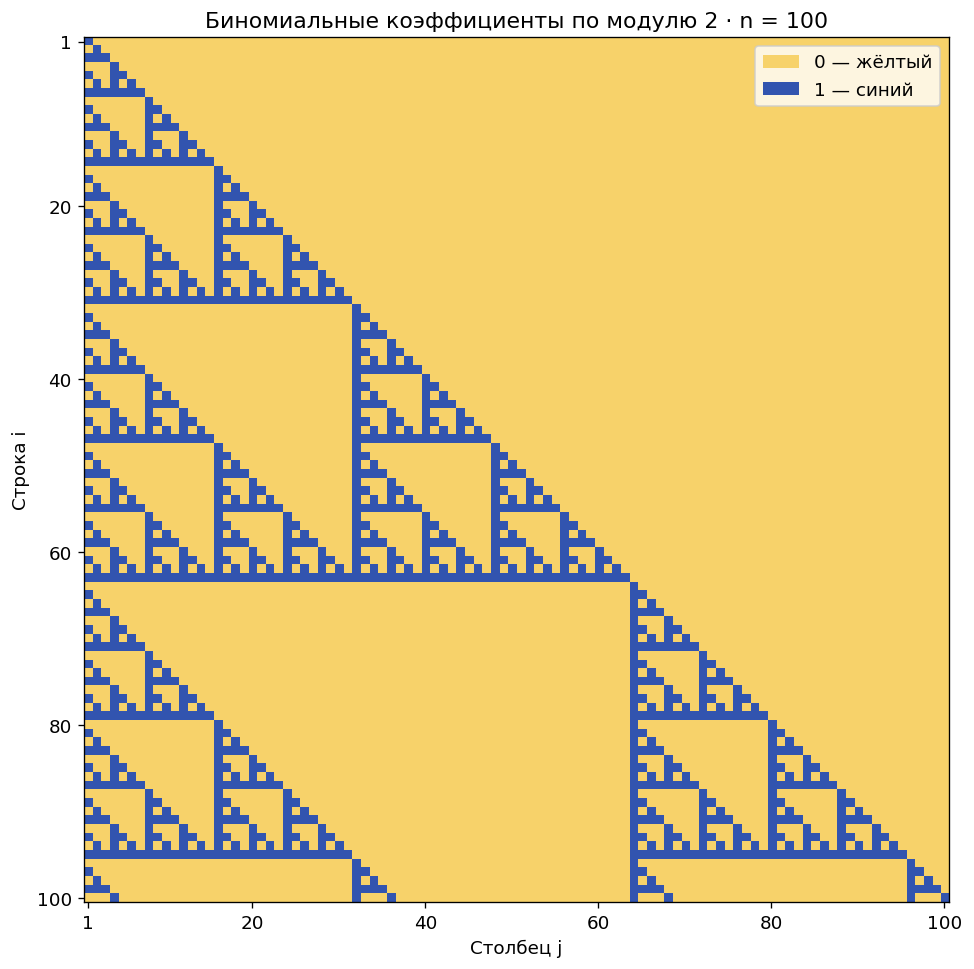

**Ответ 1.11:** Матрица $100\times100$ построена; синий — 1, жёлтый — 0.

In [13]:
def pascal_mod2(n):
    return np.array([[math.comb(i,j)%2 if j<=i else 0
                      for j in range(1,n+1)] for i in range(1,n+1)],dtype=np.int64)
P111=pascal_mod2(100)
assert np.array_equal(pascal_mod2(3),[[1,0,0],[0,1,0],[1,1,1]])
assert np.all(np.diag(P111)==1) and np.all(P111[np.triu_indices(100,1)]==0)
fig,ax=plt.subplots(figsize=(8,8),layout='constrained')
colors111=['#F7D26A','#3254AF']
ax.imshow(P111,cmap=ListedColormap(colors111),vmin=0,vmax=1,
          interpolation='nearest',extent=(0.5,100.5,100.5,0.5))
ax.set(title='Биномиальные коэффициенты по модулю 2 · n = 100',xlabel='Столбец j',ylabel='Строка i')
ax.set_xticks([1,20,40,60,80,100]); ax.set_yticks([1,20,40,60,80,100])
ax.legend(handles=[Patch(facecolor=colors111[0],label='0 — жёлтый'),
                   Patch(facecolor=colors111[1],label='1 — синий')],loc='upper right')
plt.show()
answer('1.11', 'Матрица $100\\times100$ построена; синий — 1, жёлтый — 0.')

## 1.12. Матрицы Адамара

**Условие.** Выписать $H_1,H_2,H_4$, показать $H_4=H_2\otimes H_2$ и рекурсию $H_{2^k}=H_2\otimes H_{2^{k-1}}$, затем изобразить $H_{64}$: $+1$ — оранжевый, $-1$ — синий.

**а, б)** Выберем стандартную конструкцию Сильвестра:
$$H_1=(1),\qquad H_2=\begin{pmatrix}1&1\\1&-1\end{pmatrix},$$
$$H_4=H_2\otimes H_2=\begin{pmatrix}1&1&1&1\\1&-1&1&-1\\1&1&-1&-1\\1&-1&-1&1\end{pmatrix}.$$
Здесь нижний индекс означает **порядок матрицы**; запись $H_0\equiv1$ в листке можно понимать как начальный скаляр для рекурсии, а матрица порядка 1 обозначается $H_1$.

**в)** Произведение Кронекера даёт блоки
$$H_{2^k}=\begin{pmatrix}H_{2^{k-1}}&H_{2^{k-1}}\\H_{2^{k-1}}&-H_{2^{k-1}}\end{pmatrix}.$$
Предположим $H_mH_m^T=mI_m$. Тогда прямым блочным умножением
$$\begin{pmatrix}H_m&H_m\\H_m&-H_m\end{pmatrix}
\begin{pmatrix}H_m^T&H_m^T\\H_m^T&-H_m^T\end{pmatrix}
=\begin{pmatrix}2mI_m&0\\0&2mI_m\end{pmatrix}=2mI_{2m}.$$
Это доказывает рекурсивное построение по индукции. Утверждение относится к выбранному семейству Сильвестра: само условие ортогональности не фиксирует единственный порядок строк и столбцов.

**г)** В PDF строки рисунка переставлены. Покажем два варианта: исходный порядок Сильвестра и порядок по возрастанию числа смен знака в строке (порядок Уолша), соответствующий характеру иллюстрации листка. При перестановке строк ортогональность сохраняется: $(PH)(PH)^T=P(nI)P^T=nI$.

**H₁**

[1]

**H₂**

⎡1  1 ⎤
⎢     ⎥
⎣1  -1⎦

**H₄**

⎡1  1   1   1 ⎤
⎢             ⎥
⎢1  -1  1   -1⎥
⎢             ⎥
⎢1  1   -1  -1⎥
⎢             ⎥
⎣1  -1  -1  1 ⎦

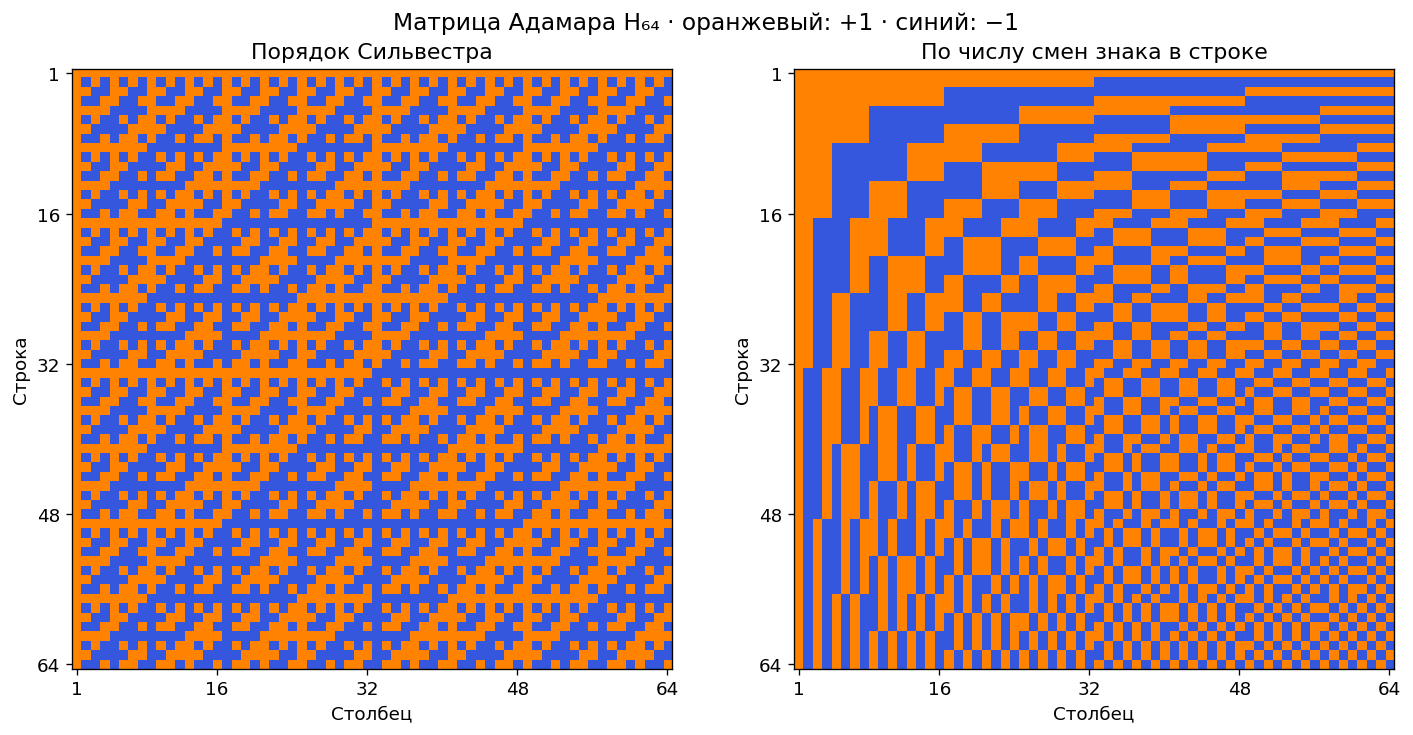

**Ответ 1.12:** $H_{2^k}=H_2\otimes H_{2^{k-1}}$ для конструкции Сильвестра; $H_{64}H_{64}^T=64I_{64}$. Матрицы и оба рисунка приведены выше.

In [14]:
def hadamard_sylvester(n):
    if n<1 or n & (n-1):
        raise ValueError('Порядок должен быть положительной степенью двойки (включая 1).')
    H=np.ones((1,1),dtype=np.int64)
    while H.shape[0]<n:
        H=np.block([[H,H],[H,-H]])
    return H
H1=hadamard_sylvester(1); H2=hadamard_sylvester(2); H4=hadamard_sylvester(4)
for name,H in [('H₁',H1),('H₂',H2),('H₄',H4)]: show(name,sp.Matrix(H))
assert np.array_equal(H4,np.kron(H2,H2))
H64=hadamard_sylvester(64)
changes112=np.count_nonzero(H64[:,1:]!=H64[:,:-1],axis=1)
H64_walsh=H64[np.argsort(changes112)]
assert np.array_equal(np.sort(changes112),np.arange(64))
for H in [H1,H2,H4,H64,H64_walsh]:
    assert np.array_equal(H@H.T,H.shape[0]*np.eye(H.shape[0],dtype=np.int64))
fig,axes=plt.subplots(1,2,figsize=(12,6),layout='constrained')
colors112=['#3557DE','#FF8200']
for ax,H,title in zip(axes,[H64,H64_walsh],['Порядок Сильвестра','По числу смен знака в строке']):
    ax.imshow(H,cmap=ListedColormap(colors112),norm=BoundaryNorm([-2,0,2],2),
              interpolation='nearest',extent=(0.5,64.5,64.5,0.5))
    ax.set(title=title,xlabel='Столбец',ylabel='Строка')
    ax.set_xticks([1,16,32,48,64]); ax.set_yticks([1,16,32,48,64])
fig.suptitle('Матрица Адамара H₆₄ · оранжевый: +1 · синий: −1',fontsize=14)
plt.show()
answer('1.12', r'$H_{2^k}=H_2\otimes H_{2^{k-1}}$ для конструкции Сильвестра; $H_{64}H_{64}^T=64I_{64}$. Матрицы и оба рисунка приведены выше.')

## 1.13. Комплексное собственное значение и собственный вектор

**Условие.**
$$A=\begin{pmatrix}14&10&21\\12&15&26\\18&11&27\end{pmatrix}.$$
Найти собственное значение $Z$ с наибольшей мнимой частью и соответствующий вектор $X=(1,U,V)^T$. Указать $\operatorname{Im}Z$ и $\operatorname{Re}U$.

**Решение.** Находим корни характеристического многочлена $\det(zI-A)$ и выбираем корень с максимальной мнимой частью. Вектор, ортогональный первым двум строкам $A-zI$, получается их векторным произведением:
$$v(z)=\begin{pmatrix}21z-55\\26z-112\\z^2-29z+90\end{pmatrix}.$$
При корне характеристического многочлена третье уравнение также выполняется. Для выбранного $Z$ первая координата ненулевая, поэтому
$$X=\begin{pmatrix}1\\\dfrac{26Z-112}{21Z-55}\\\dfrac{Z^2-29Z+90}{21Z-55}\end{pmatrix}.$$
Численные корни считаем с 30 значащими цифрами и проверяем невязку $AX-ZX$.

In [15]:
A113=sp.Matrix([[14,10,21],[12,15,26],[18,11,27]])
z=sp.symbols('z')
chi113=A113.charpoly(z).as_expr()
roots113=sp.nroots(chi113,n=30,maxsteps=200)
Z113=max(roots113,key=lambda value:float(sp.im(value)))
U113=((26*Z113-112)/(21*Z113-55)).evalf(25)
V113=((Z113**2-29*Z113+90)/(21*Z113-55)).evalf(25)
X113=sp.Matrix([1,U113,V113])
show('Характеристический многочлен',chi113)
show('Все собственные значения',roots113)
show('Z',Z113.evalf(14)); show('X = (1,U,V)ᵀ',X113.evalf(14))
residual113=max(abs(complex(value.evalf())) for value in A113*X113-Z113*X113)
print(f'Максимальная абсолютная невязка: {residual113:.3e}')
assert residual113<1e-20
answer('1.13', f'$\\operatorname{{Im}}Z\\approx {float(sp.im(Z113)):.9f}$; $\\operatorname{{Re}}U\\approx {float(sp.re(U113)):.9f}$.')

**Характеристический многочлен**

**Все собственные значения**

**Z**

**X = (1,U,V)ᵀ**

⎡                 1.0                 ⎤
⎢                                     ⎥
⎢ 3.7478197293948 + 1.3308467741437⋅ⅈ ⎥
⎢                                     ⎥
⎣-2.3575884268165 - 0.61731801871477⋅ⅈ⎦

Максимальная абсолютная невязка: 1.218e-24


**Ответ 1.13:** $\operatorname{Im}Z\approx 0.344789348$; $\operatorname{Re}U\approx 3.747819729$.

## 1.14. Минимальный многочлен матрицы

**Условие.** Найти минимальный многочлен приведённой ниже матрицы порядка 7.

**Решение.** Минимальный многочлен $m_A(t)$ — нормированный многочлен наименьшей степени, для которого $m_A(A)=0$. Характеристический многочлен сам по себе не гарантирует минимальность.

Будем искать **первую** линейную зависимость матриц $I,A,A^2,\ldots$. Развернём каждую в столбец из 49 элементов. Если $A^d$ впервые выражается через предыдущие степени,
$$A^d+c_{d-1}A^{d-1}+\cdots+c_1A+c_0I=0,$$
то $m_A(t)=t^d+c_{d-1}t^{d-1}+\cdots+c_0$. Ранг столбцов $I,\ldots,A^{d-1}$, равный $d$, доказывает отсутствие многочлена меньшей степени. Все операции выполним над рациональными числами.

В данном случае $\chi_A(t)=t^3(t-1)^4$. Матрицы $I,A,A^2,A^3,A^4$ линейно независимы (ранг равен 5), а первая зависимость имеет вид
$$A^5-2A^4+A^3=0.$$
Поэтому $\boxed{m_A(t)=t^5-2t^4+t^3=t^3(t-1)^2}$. Ни один ненулевой многочлен степени меньше 5 матрицу не аннулирует.


In [16]:
A114=sp.Matrix([
[-3,7,-6,-1,8,-3,-2],
[1,-5,8,-3,-5,4,-5],
[1,3,-4,6,-2,0,8],
[-1,11,-12,9,3,-3,9],
[-3,11,-12,5,8,-4,6],
[-3,2,1,-4,4,1,-7],
[1,-5,6,-2,-4,3,-2]])
show('Исходная матрица A',A114)
lambda_poly=sp.symbols('t')
chi114=sp.factor(A114.charpoly(lambda_poly).as_expr())
show('Характеристический многочлен',chi114)
powers114=[sp.eye(7)]
rank_rows114=[]
for degree114 in range(1,8):
    powers114.append(powers114[-1]*A114)
    previous_columns114=sp.Matrix.hstack(*[M.reshape(49,1) for M in powers114[:-1]])
    all_columns114=previous_columns114.row_join(powers114[-1].reshape(49,1))
    rank_before114=previous_columns114.rank()
    rank_all114=all_columns114.rank()
    rank_rows114.append((degree114,rank_before114,rank_all114))
    if rank_before114==rank_all114:
        coefficients114=previous_columns114.gauss_jordan_solve(-powers114[-1].reshape(49,1))[0]
        minimal114=sp.expand(lambda_poly**degree114+sum(coefficients114[i]*lambda_poly**i for i in range(degree114)))
        break
else:
    raise AssertionError('Зависимость должна появиться не позже степени 7.')
show('Столбцы: d, rank(I,…,A^(d−1)), rank(I,…,A^d)',sp.Matrix(rank_rows114))
show('Минимальный многочлен: факторизация',sp.factor(minimal114))
show('Минимальный многочлен: раскрытый вид',minimal114)
assert rank_before114==degree114
assert poly_at_matrix(minimal114,A114,lambda_poly)==sp.zeros(7)
assert sp.rem(chi114,minimal114,lambda_poly)==0
answer('1.14', '$m_A(t)='+sp.latex(sp.factor(minimal114))+'$. Минимальность подтверждена независимостью предыдущих степеней.')

**Исходная матрица A**

⎡-3  7   -6   -1  8   -3  -2⎤
⎢                           ⎥
⎢1   -5   8   -3  -5  4   -5⎥
⎢                           ⎥
⎢1   3   -4   6   -2  0   8 ⎥
⎢                           ⎥
⎢-1  11  -12  9   3   -3  9 ⎥
⎢                           ⎥
⎢-3  11  -12  5   8   -4  6 ⎥
⎢                           ⎥
⎢-3  2    1   -4  4   1   -7⎥
⎢                           ⎥
⎣1   -5   6   -2  -4  3   -2⎦

**Характеристический многочлен**

**Столбцы: d, rank(I,…,A^(d−1)), rank(I,…,A^d)**

⎡1  1  2⎤
⎢       ⎥
⎢2  2  3⎥
⎢       ⎥
⎢3  3  4⎥
⎢       ⎥
⎢4  4  5⎥
⎢       ⎥
⎣5  5  5⎦

**Минимальный многочлен: факторизация**

**Минимальный многочлен: раскрытый вид**

**Ответ 1.14:** $m_A(t)=t^{3} \left(t - 1\right)^{2}$. Минимальность подтверждена независимостью предыдущих степеней.

## 1.15. Собственный ортонормированный базис

**Условие.** Оператор в исходном ортонормированном базисе имеет матрицу
$$A=\begin{pmatrix}17&-8&4\\-8&17&-4\\4&-4&11\end{pmatrix}.$$
Найти собственный ортонормированный базис и матрицу оператора в нём.

**Решение.** Матрица симметрична. Её собственные значения — 9 (кратность 2) и 27 (кратность 1). В собственном подпространстве для 9 выберем два взаимно ортогональных вектора; затем нормируем все векторы:
$$v_1=\frac1{\sqrt2}(1,1,0)^T,\qquad
v_2=\frac1{3\sqrt2}(1,-1,-4)^T,\qquad
v_3=\frac13(2,-2,1)^T.$$
Пусть $P=(v_1\ v_2\ v_3)$. Тогда $P^TP=I$ и $P^TAP=\operatorname{diag}(9,9,27)$. Столбцы $P$ задают новый базис в исходных координатах; связь координат $x=Py$.

In [17]:
A115=sp.Matrix([[17,-8,4],[-8,17,-4],[4,-4,11]])
P115=sp.Matrix.hstack(sp.Matrix([1,1,0])/sp.sqrt(2),
                       sp.Matrix([1,-1,-4])/(3*sp.sqrt(2)),sp.Matrix([2,-2,1])/3)
D115=sp.simplify(P115.T*A115*P115)
show('Характеристический многочлен',sp.factor(A115.charpoly(z).as_expr()))
show('P: столбцы — собственный ортонормированный базис',P115)
show('Матрица в новом базисе',D115)
assert sp.simplify(P115.T*P115)==sp.eye(3)
assert D115==sp.diag(9,9,27)
assert sp.simplify(A115*P115-P115*D115)==sp.zeros(3)
answer('1.15', r'Базис: $(1,1,0)/\sqrt2$, $(1,-1,-4)/(3\sqrt2)$, $(2,-2,1)/3$. Матрица: $\operatorname{diag}(9,9,27)$.')

**Характеристический многочлен**

**P: столбцы — собственный ортонормированный базис**

⎡√2    √2        ⎤
⎢──    ──    2/3 ⎥
⎢2     6         ⎥
⎢                ⎥
⎢√2   -√2        ⎥
⎢──   ────   -2/3⎥
⎢2     6         ⎥
⎢                ⎥
⎢    -2⋅√2       ⎥
⎢0   ──────  1/3 ⎥
⎣      3         ⎦

**Матрица в новом базисе**

⎡9  0  0 ⎤
⎢        ⎥
⎢0  9  0 ⎥
⎢        ⎥
⎣0  0  27⎦

**Ответ 1.15:** Базис: $(1,1,0)/\sqrt2$, $(1,-1,-4)/(3\sqrt2)$, $(2,-2,1)/3$. Матрица: $\operatorname{diag}(9,9,27)$.

## 1.16. Главные оси квадратичной функции

**Условие.**
$$f=3x_1^2+8x_1x_2-3x_2^2+4x_3^2-4x_3x_4+x_4^2.$$

**Решение.** Коэффициенты смешанных произведений делятся пополам при записи симметрической матрицы:
$$A=\begin{pmatrix}3&4&0&0\\4&-3&0&0\\0&0&4&-2\\0&0&-2&1\end{pmatrix}.$$
Первый блок имеет собственные значения $5,-5$ с нормированными векторами $(2,1)/\sqrt5$, $(-1,2)/\sqrt5$; второй — значения $5,0$ с векторами $(2,-1)/\sqrt5$, $(1,2)/\sqrt5$.
Получаем ортогональное преобразование $x=Py$:
$$\begin{cases}
x_1=(2y_1-y_2)/\sqrt5,\\x_2=(y_1+2y_2)/\sqrt5,\\
x_3=(2y_3+y_4)/\sqrt5,\\x_4=(-y_3+2y_4)/\sqrt5.
\end{cases}$$
В главных осях $\boxed{f=5y_1^2-5y_2^2+5y_3^2}$; коэффициент при $y_4^2$ нулевой. Форма вырождена (ранг 3) и неопределённа.

In [18]:
A116=sp.Matrix([[3,4,0,0],[4,-3,0,0],[0,0,4,-2],[0,0,-2,1]])
P116=sp.Matrix([[2,-1,0,0],[1,2,0,0],[0,0,2,1],[0,0,-1,2]])/sp.sqrt(5)
D116=sp.simplify(P116.T*A116*P116)
y1,y2,y3,y4=sp.symbols('y_1 y_2 y_3 y_4',real=True)
y116=sp.Matrix([y1,y2,y3,y4])
x116=P116*y116
f116=sp.expand((x116.T*A116*x116)[0])
show('Ортогональная матрица P',P116)
show('Диагональная матрица',D116)
show('Функция в главных осях',f116)
assert sp.simplify(P116.T*P116)==sp.eye(4)
assert D116==sp.diag(5,-5,5,0)
assert f116==5*y1**2-5*y2**2+5*y3**2
answer('1.16', r'$x=Py$ с матрицей $P$ выше; $f=5y_1^2-5y_2^2+5y_3^2$.')

**Ортогональная матрица P**

⎡2⋅√5  -√5             ⎤
⎢────  ────   0     0  ⎥
⎢ 5     5              ⎥
⎢                      ⎥
⎢ √5   2⋅√5            ⎥
⎢ ──   ────   0     0  ⎥
⎢ 5     5              ⎥
⎢                      ⎥
⎢            2⋅√5   √5 ⎥
⎢ 0     0    ────   ── ⎥
⎢             5     5  ⎥
⎢                      ⎥
⎢            -√5   2⋅√5⎥
⎢ 0     0    ────  ────⎥
⎣             5     5  ⎦

**Диагональная матрица**

⎡5  0   0  0⎤
⎢           ⎥
⎢0  -5  0  0⎥
⎢           ⎥
⎢0  0   5  0⎥
⎢           ⎥
⎣0  0   0  0⎦

**Функция в главных осях**

**Ответ 1.16:** $x=Py$ с матрицей $P$ выше; $f=5y_1^2-5y_2^2+5y_3^2$.

## 1.17. Кривые второго порядка

**Условие.** Определить тип, каноническое уравнение и каноническую систему координат:

а) $5x^2+4xy+8y^2-32x-56y+80=0$;

б) $5x^2+12xy-22x-12y-19=0$.

**Общий способ.** Для $F(r)=r^TAr+\ell^Tr+c$ центр $r_0$ удовлетворяет $2Ar_0+\ell=0$. После переноса $r=r_0+Pu$, где столбцы $P$ — ортонормированные собственные векторы $A$, линейные и смешанные члены исчезают.

### а) Эллипс

$$A_a=\begin{pmatrix}5&2\\2&8\end{pmatrix},\quad r_{0a}=(2,3)^T,\quad
P_a=\frac1{\sqrt5}\begin{pmatrix}2&1\\-1&2\end{pmatrix}.$$
Собственные значения — 4 и 9, значение функции в центре — $-36$.
Замена координат и её обратная запись:
$$x=2+\frac{2u+v}{\sqrt5},\qquad y=3+\frac{-u+2v}{\sqrt5};$$
$$u=\frac{2(x-2)-(y-3)}{\sqrt5},\qquad v=\frac{(x-2)+2(y-3)}{\sqrt5}.$$
Каноническое уравнение $4u^2+9v^2=36$, то есть
$$\boxed{\frac{u^2}{9}+\frac{v^2}{4}=1}.$$
Это эллипс с полуосями 3 и 2. Новое начало — $(2,3)$; орты осей — $(2,-1)/\sqrt5$, $(1,2)/\sqrt5$.

### б) Гипербола

$$A_b=\begin{pmatrix}5&6\\6&0\end{pmatrix},\quad r_{0b}=(1,1)^T,\quad
P_b=\frac1{\sqrt{13}}\begin{pmatrix}3&-2\\2&3\end{pmatrix}.$$
Собственные значения — 9 и $-4$, значение функции в центре — $-36$.
$$x=1+\frac{3u-2v}{\sqrt{13}},\qquad y=1+\frac{2u+3v}{\sqrt{13}};$$
$$u=\frac{3(x-1)+2(y-1)}{\sqrt{13}},\qquad v=\frac{-2(x-1)+3(y-1)}{\sqrt{13}}.$$
Каноническое уравнение $9u^2-4v^2=36$, то есть
$$\boxed{\frac{u^2}{4}-\frac{v^2}{9}=1}.$$
Это гипербола с действительной полуосью 2 и мнимой полуосью 3. Новое начало — $(1,1)$; орты осей — $(3,2)/\sqrt{13}$, $(-2,3)/\sqrt{13}$. Асимптоты в новых координатах: $v=\pm\frac32u$.

In [19]:
u,v=sp.symbols('u v',real=True)
y=sp.symbols('y',real=True)
Fa117=5*x**2+4*x*y+8*y**2-32*x-56*y+80
Fb117=5*x**2+12*x*y-22*x-12*y-19
Pa117=sp.Matrix([[2,1],[-1,2]])/sp.sqrt(5)
Pb117=sp.Matrix([[3,-2],[2,3]])/sp.sqrt(13)
ca117=sp.Matrix([2,3]); cb117=sp.Matrix([1,1])
for label,F,P,center,expected in [
    ('а',Fa117,Pa117,ca117,4*u**2+9*v**2-36),
    ('б',Fb117,Pb117,cb117,9*u**2-4*v**2-36)]:
    transformed=center+P*sp.Matrix([u,v])
    canonical=sp.expand(F.subs({x:transformed[0],y:transformed[1]},simultaneous=True))
    show(f'{label}) Результат точной подстановки',canonical)
    assert sp.simplify(P.T*P)==sp.eye(2)
    assert canonical==expected
    assert all(sp.diff(F,var).subs({x:center[0],y:center[1]})==0 for var in [x,y])
answer('1.17', r'а) Эллипс $u^2/9+v^2/4=1$, центр $(2,3)$; б) гипербола $u^2/4-v^2/9=1$, центр $(1,1)$. Канонические оси указаны выше.')

**а) Результат точной подстановки**

**б) Результат точной подстановки**

**Ответ 1.17:** а) Эллипс $u^2/9+v^2/4=1$, центр $(2,3)$; б) гипербола $u^2/4-v^2/9=1$, центр $(1,1)$. Канонические оси указаны выше.

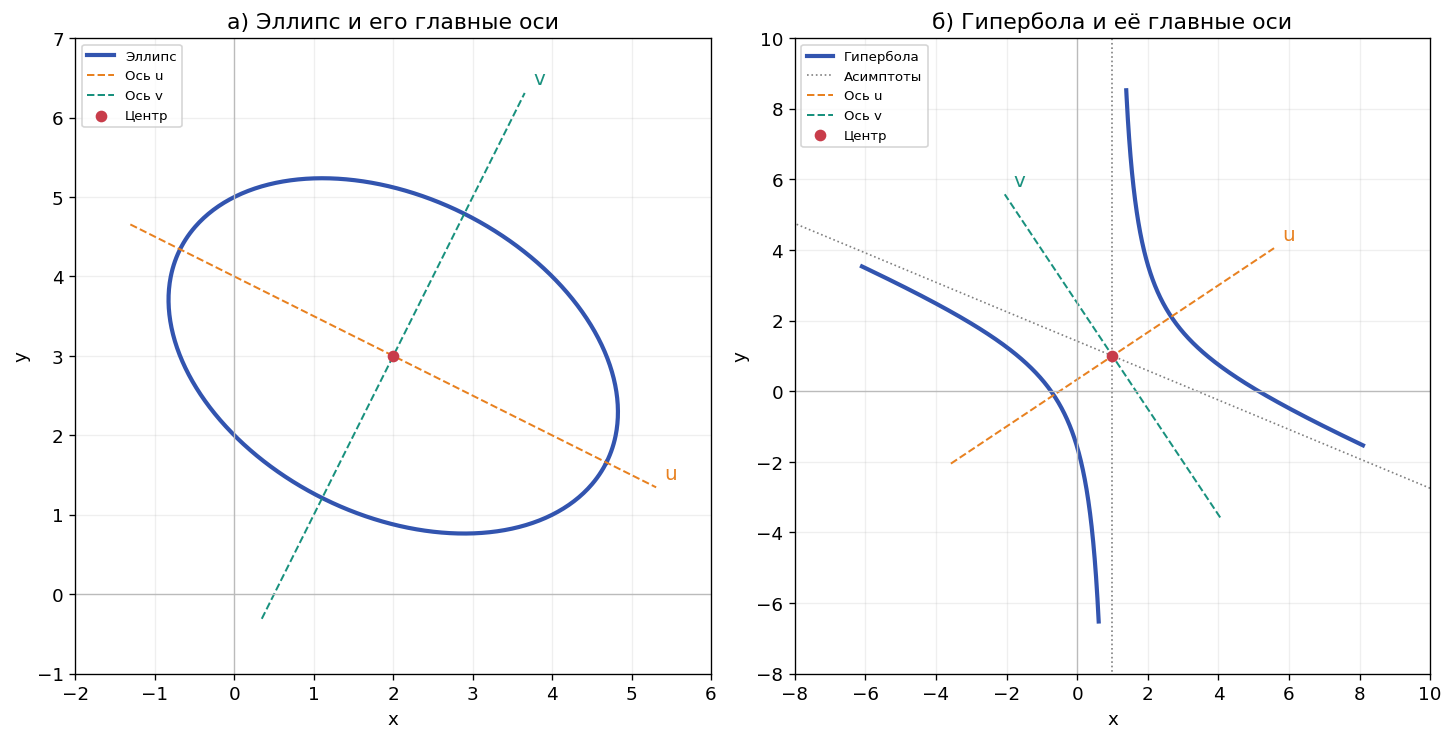

In [20]:
fig,axes=plt.subplots(1,2,figsize=(12,6),layout='constrained')
Pa=np.array(Pa117,dtype=float); Pb=np.array(Pb117,dtype=float)
ca=np.array([2.,3.]); cb=np.array([1.,1.])
angle=np.linspace(0,2*np.pi,500)
ellipse=ca[:,None]+Pa@np.vstack([3*np.cos(angle),2*np.sin(angle)])
axes[0].plot(*ellipse,color='#3254AF',lw=2.5,label='Эллипс')
tau=np.linspace(-1.45,1.45,400)
for sign in [-1,1]:
    branch=cb[:,None]+Pb@np.vstack([sign*2*np.cosh(tau),3*np.sinh(tau)])
    axes[1].plot(*branch,color='#3254AF',lw=2.5,label='Гипербола' if sign==1 else None)
for sign in [-1,1]:
    us=np.linspace(-6,6,2)
    asymptote=cb[:,None]+Pb@np.vstack([us,sign*1.5*us])
    axes[1].plot(*asymptote,color='gray',lw=1,ls=':',label='Асимптоты' if sign==1 else None)
for ax,P,c,title,limits in zip(axes,[Pa,Pb],[ca,cb],
    ['а) Эллипс и его главные оси','б) Гипербола и её главные оси'],[(-2,6,-1,7),(-8,10,-8,10)]):
    for j,color,name in [(0,'#E88120','u'),(1,'#19917E','v')]:
        length=3.7 if ax is axes[0] else 5.5
        segment=c[:,None]+P[:,j,None]*np.array([-length,length])
        ax.plot(*segment,color=color,ls='--',lw=1.2,label=f'Ось {name}')
        point=c+length*P[:,j]
        ax.annotate(name,point,xytext=(5,5),textcoords='offset points',color=color,fontsize=12)
    ax.scatter(*c,color='#C83C4A',zorder=5,label='Центр')
    ax.axhline(0,color='#bbbbbb',lw=0.8); ax.axvline(0,color='#bbbbbb',lw=0.8)
    ax.set(title=title,xlabel='x',ylabel='y',xlim=limits[:2],ylim=limits[2:])
    ax.set_aspect('equal'); ax.grid(alpha=0.2); ax.legend(fontsize=8,loc='upper left')
plt.show()

## 1.18. Положительная определённость

**Условие.** При каких $\lambda$ форма
$$Q=x_1^2+4x_2^2+x_3^2+2\lambda x_1x_2+10x_1x_3+6x_2x_3$$
положительно определена?

**Решение.** Для положительной определённости необходимо $Q(x)>0$ при **каждом** ненулевом $x$. Возьмём $x=(1,0,-1)^T$. Члены с $\lambda$ и $x_2$ исчезают, а $Q(1,0,-1)=1+1-10=-8<0$ независимо от параметра.

Также главный минор по индексам $(1,3)$ равен $\det\begin{pmatrix}1&5\\5&1\end{pmatrix}=-24<0$, что несовместимо с положительной определённостью. При $x=(1,0,0)^T$ значение положительно, поэтому форма при любом $\lambda$ является неопределённой.

In [21]:
lam=sp.symbols('lambda',real=True)
A118=sp.Matrix([[1,lam,5],[lam,4,3],[5,3,1]])
negative118=sp.Matrix([1,0,-1]); positive118=sp.Matrix([1,0,0])
show('Матрица формы',A118)
show('Q(1,0,−1)',(negative118.T*A118*negative118)[0])
show('Q(1,0,0)',(positive118.T*A118*positive118)[0])
assert (negative118.T*A118*negative118)[0]==-8
assert (positive118.T*A118*positive118)[0]==1
answer('1.18', r'Таких $\lambda\in\mathbb R$ нет; форма неопределённа при любом $\lambda$.')

**Матрица формы**

⎡1  λ  5⎤
⎢       ⎥
⎢λ  4  3⎥
⎢       ⎥
⎣5  3  1⎦

**Q(1,0,−1)**

**Q(1,0,0)**

**Ответ 1.18:** Таких $\lambda\in\mathbb R$ нет; форма неопределённа при любом $\lambda$.

## 1.19. Отрицательная определённость

**Условие.** При каких $\lambda$ форма
$$Q=\lambda x_1^2-2x_2^2-3x_3^2+2x_1x_2-2x_1x_3+2x_2x_3$$
отрицательно определена?

**Решение.** Её симметрическая матрица
$$A=\begin{pmatrix}\lambda&1&-1\\1&-2&1\\-1&1&-3\end{pmatrix}.$$
По критерию Сильвестра для отрицательной определённости ведущие главные миноры должны чередовать знаки: $\Delta_1<0$, $\Delta_2>0$, $\Delta_3<0$.
$$\Delta_1=\lambda,\qquad\Delta_2=-2\lambda-1,\qquad\Delta_3=5\lambda+3.$$
Получаем $\lambda<0$, $\lambda<-1/2$, $\lambda<-3/5$; пересечение равно $\boxed{\lambda<-3/5}$.
Граница $\lambda=-3/5$ не входит: определитель равен нулю и ненулевой вектор из ядра даёт значение формы 0.

In [22]:
A119=sp.Matrix([[lam,1,-1],[1,-2,1],[-1,1,-3]])
minors119=[sp.expand(A119[:i,:i].det()) for i in range(1,4)]
show('Ведущие главные миноры',minors119)
condition119=sp.reduce_inequalities([minors119[0]<0,minors119[1]>0,minors119[2]<0],lam)
show('Пересечение условий',condition119)
boundary119=A119.subs(lam,-sp.Rational(3,5))
null119=boundary119.nullspace()[0]
show('Ненулевой вектор ядра на границе',null119)
assert boundary119*null119==sp.zeros(3,1)
assert all(value<0 for value in np.linalg.eigvalsh(np.array(A119.subs(lam,-1),dtype=float)))
answer('1.19', r'$\lambda\in(-\infty,-3/5)$. Граница исключается.')

**Ведущие главные миноры**

**Пересечение условий**

**Ненулевой вектор ядра на границе**

⎡-5⎤
⎢  ⎥
⎢-2⎥
⎢  ⎥
⎣1 ⎦

**Ответ 1.19:** $\lambda\in(-\infty,-3/5)$. Граница исключается.

## 1.20. Эквивалентность квадратичных форм над $\mathbb R$

**Условие, как напечатано в PDF.**
$$Q_1=2x_1^2+9x_2^2+3x_3^2+8x_1x_2-4x_1x_3-10x_2x_3,$$
$$Q_2=2x_1+3x_2^2+6x_3^2-4x_1x_2-4x_1x_3+8x_2x_3.$$

### Буквальное прочтение

В первом слагаемом $Q_2$ у $x_1$ отсутствует квадрат. Поэтому это **не квадратичная форма** (не однородный многочлен второй степени). При невырожденной линейной замене $x=Py$ ненулевая линейная часть остаётся ненулевой: её коэффициенты равны $(2,0,0)P\ne0$. Получить из неё однородную $Q_1$ невозможно. В буквальной записи говорить об эквивалентности двух квадратичных форм некорректно; как многочлены относительно невырожденных линейных замен они неэквивалентны.

### При предполагаемой опечатке: $2x_1^2$ вместо $2x_1$

Рассмотрим исправленную однородную форму $\widetilde Q_2$. Выделим полные квадраты:
$$Q_1=2(x_1+2x_2-x_3)^2+(x_2-x_3)^2,$$
$$\widetilde Q_2=2(x_1-x_2-x_3)^2+(x_2+2x_3)^2.$$
В обоих случаях линейные выражения в скобках независимы; дополнив их координатой $x_3$, получаем обратимые замены. Обе формы приводятся к $2u_1^2+u_2^2$, а после масштабирования — к $v_1^2+v_2^2+0v_3^2$.

По закону инерции обе формы имеют инерцию $(n_+,n_-,n_0)=(2,0,1)$ и **эквивалентны над $\mathbb R$**. Можно предъявить замену явно:
$$x=Py,\qquad P=\begin{pmatrix}1&-3&-6\\0&1&3\\0&0&1\end{pmatrix},\qquad \det P=1.$$
Она даёт $Q_1(Py)=\widetilde Q_2(y)$, или $P^TA_1P=A_2$.

In [23]:
x1,x2,x3=sp.symbols('x_1 x_2 x_3',real=True)
xx120=sp.Matrix([x1,x2,x3])
A120_1=sp.Matrix([[2,4,-2],[4,9,-5],[-2,-5,3]])
A120_2=sp.Matrix([[2,-2,-2],[-2,3,4],[-2,4,6]])
Q120_1=sp.expand((xx120.T*A120_1*xx120)[0])
Q120_2=sp.expand((xx120.T*A120_2*xx120)[0])
assert sp.expand(Q120_1-2*(x1+2*x2-x3)**2-(x2-x3)**2)==0
assert sp.expand(Q120_2-2*(x1-x2-x3)**2-(x2+2*x3)**2)==0
P120=sp.Matrix([[1,-3,-6],[0,1,3],[0,0,1]])
show('Матрица замены P',P120)
show('Pᵀ A₁ P',P120.T*A120_1*P120)
assert P120.det()==1 and P120.T*A120_1*P120==A120_2
assert A120_1.rank()==A120_2.rank()==2
Q120_literal=Q120_2-2*x1**2+2*x1
print('Линейная часть исходного Q₂:',2*x1)
assert sp.Poly(Q120_literal,x1,x2,x3).coeff_monomial(x1)==2
answer('1.20', r'Буквально: $Q_2$ не является квадратичной формой. Если $2x_1$ исправить на $2x_1^2$, формы эквивалентны: обе имеют инерцию $(2,0,1)$; явная замена приведена выше.')

**Матрица замены P**

⎡1  -3  -6⎤
⎢         ⎥
⎢0  1   3 ⎥
⎢         ⎥
⎣0  0   1 ⎦

**Pᵀ A₁ P**

⎡2   -2  -2⎤
⎢          ⎥
⎢-2  3   4 ⎥
⎢          ⎥
⎣-2  4   6 ⎦

Линейная часть исходного Q₂: 2*x_1


**Ответ 1.20:** Буквально: $Q_2$ не является квадратичной формой. Если $2x_1$ исправить на $2x_1^2$, формы эквивалентны: обе имеют инерцию $(2,0,1)$; явная замена приведена выше.

## Сводка ответов и итоговая проверка

Ниже автоматически собраны результаты всех 20 задач. Формулы и точные матрицы приведены в соответствующих разделах. Десятичные числа являются приближениями; в № 1.20 вывод зависит от прочтения опечатки.

In [24]:
expected_tasks={f'1.{i}' for i in range(1,21)}
assert set(answers)==expected_tasks
for i in range(1,21):
    number=f'1.{i}'
    display(Markdown(f'**{number}.** {answers[number]}'))
print('\nГотово: все 20 задач решены; все встроенные проверки выполнены успешно.')

**1.1.** $x=\left(\frac{-11-8t}{7},\frac{-6+2t}{7},\frac{4+t}{7},t\right)^T$, $t\in\mathbb R$.

**1.2.** $x=(4-2s-3t,\ 7-5s-6t,\ s,\ t,\ 8)^T$, $s,t\in\mathbb R$.

**1.3.** $y=14027-4262x$; $a=14027$, $b=-4262$.

**1.4.** $\left[\begin{matrix}7 & 4 & 5 & 11\\6 & 4 & -1 & 6\\0 & 0 & 6 & 12\\-1 & 2 & 1 & 3\end{matrix}\right]$.

**1.5.** а) $1$; б) $(-1)^{n-1}n$; в) $(-1)^{n-1}(n-1)2^{n-2}$ при $n\ge2$, при $n=1$ — $0$.

**1.6.** $160$; глобальный максимум подтверждён полным точным перебором после сведения.

**1.7.** $\det A\approx 0.258979114$; $\operatorname{tr}(A^{-1})\approx 80002.702766086$.

**1.8.** $\min B_{ij}=-110/107\approx -1.028037383$; $\sum B_{ij}\approx -2054.438267$.

**1.9.** $\max S_{4,70}\approx 3.609679$; $\max B_4\approx 3.611175$; $k_{\min}=89$.

**1.10.** $\det M=16 x^{2} - 116 x + 576$; $a=16$, $b=-116$, $c=576$.

**1.11.** Матрица $100\times100$ построена; синий — 1, жёлтый — 0.

**1.12.** $H_{2^k}=H_2\otimes H_{2^{k-1}}$ для конструкции Сильвестра; $H_{64}H_{64}^T=64I_{64}$. Матрицы и оба рисунка приведены выше.

**1.13.** $\operatorname{Im}Z\approx 0.344789348$; $\operatorname{Re}U\approx 3.747819729$.

**1.14.** $m_A(t)=t^{3} \left(t - 1\right)^{2}$. Минимальность подтверждена независимостью предыдущих степеней.

**1.15.** Базис: $(1,1,0)/\sqrt2$, $(1,-1,-4)/(3\sqrt2)$, $(2,-2,1)/3$. Матрица: $\operatorname{diag}(9,9,27)$.

**1.16.** $x=Py$ с матрицей $P$ выше; $f=5y_1^2-5y_2^2+5y_3^2$.

**1.17.** а) Эллипс $u^2/9+v^2/4=1$, центр $(2,3)$; б) гипербола $u^2/4-v^2/9=1$, центр $(1,1)$. Канонические оси указаны выше.

**1.18.** Таких $\lambda\in\mathbb R$ нет; форма неопределённа при любом $\lambda$.

**1.19.** $\lambda\in(-\infty,-3/5)$. Граница исключается.

**1.20.** Буквально: $Q_2$ не является квадратичной формой. Если $2x_1$ исправить на $2x_1^2$, формы эквивалентны: обе имеют инерцию $(2,0,1)$; явная замена приведена выше.


Готово: все 20 задач решены; все встроенные проверки выполнены успешно.
